# DL077 可解释性与因果主张

对应原catalog T5。重启内核并按顺序运行；实验离线，全部数据本地生成。正文解释见lecture.md，练习见lab.md。

In [1]:
# 引入共享的完整实验实现；无网络调用。
from experiment import run
# 另存结果，保留发行版outputs证据。
results = run('notebook_outputs')
# 显示真实训练和评价的结果。
results

{'test_rmse': 0.08887379241783663,
 'point': [0.8, 4.0],
 'baseline_zero': [0.0, 0.0],
 'baseline_alternative': [0.5, 2.5],
 'prediction': 3.9987162283754936,
 'gradient': [0.01421751019840789, 1.0076220621488043],
 'ig_zero': [-0.0034361504747634007, 3.995315405209069],
 'ig_alternative': [0.004103197837707085, 1.503372248708144],
 'completeness_error': 2.2065115956593218e-08,
 'randomization': {'head': {'relative_l2_change': 1.037912068416254,
   'signed_cosine': -0.9269482639735486},
  'all': {'relative_l2_change': 1.0109568998590044,
   'signed_cosine': -0.6203859841421425}},
 'perturbation': {'delta': [0.001, 0.01, 0.1, 1.0],
  'actual_change': [0.001007623210122155,
   0.010076335974184225,
   0.10077426568935532,
   1.0089790904900253],
  'linearized_change': [0.0010076220621488045,
   0.010076220621488044,
   0.10076220621488044,
   1.0076220621488043]},
 'causal': {'observational_x_slope': 4.593264689543422,
  'u_adjusted_x_slope': 1.9836347162746741,
  'do_x_effect_per_unit':

## 数字数组与复核
NPZ保存普通数值数组；关闭pickle并列出形状，确认样本与字段含义。

In [2]:
# 读取本次Notebook真正产生的数据。
import numpy as np
data = np.load('notebook_outputs/data.npz', allow_pickle=False)
# 显示每个字段的形状，结合data_dictionary.md阅读。
{key: data[key].shape for key in data.files}

{'train_x': (600, 2),
 'train_y': (600,),
 'train_exogenous': (600, 4),
 'test_x': (400, 2),
 'test_y': (400,),
 'test_exogenous': (400, 4),
 'do_x0': (400,),
 'do_x1': (400,),
 'y0': (400,),
 'y1': (400,),
 'z0': (400,),
 'z1': (400,)}

## 自动数学核查
运行数值梯度、结构机制或后验检查；失败会明确中止。

In [3]:
# unittest断言在普通和优化解释器下都生效。
import unittest
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
checked = unittest.TextTestRunner(verbosity=2).run(suite)
if not checked.wasSuccessful():
    raise RuntimeError('Numerical checks failed')

test_baseline_identity (test_experiment.ExplanationTests.test_baseline_identity) ... 

ok


test_different_split (test_experiment.ExplanationTests.test_different_split) ... 

ok


test_fit_learns_proxy (test_experiment.ExplanationTests.test_fit_learns_proxy) ... 

...

test_parameter_randomization_changes_gradient (test_experiment.ExplanationTests.test_parameter_randomization_changes_gradient) ... 

ok


test_proxy_does_not_enter_y_equation (test_experiment.ExplanationTests.test_proxy_does_not_enter_y_equation) ... 

ok


----------------------------------------------------------------------
Ran 10 tests in 0.179s

OK


## 内嵌实验结果图
以下图直接使用本Notebook新产生的数组，并未复制旧的显示输出。

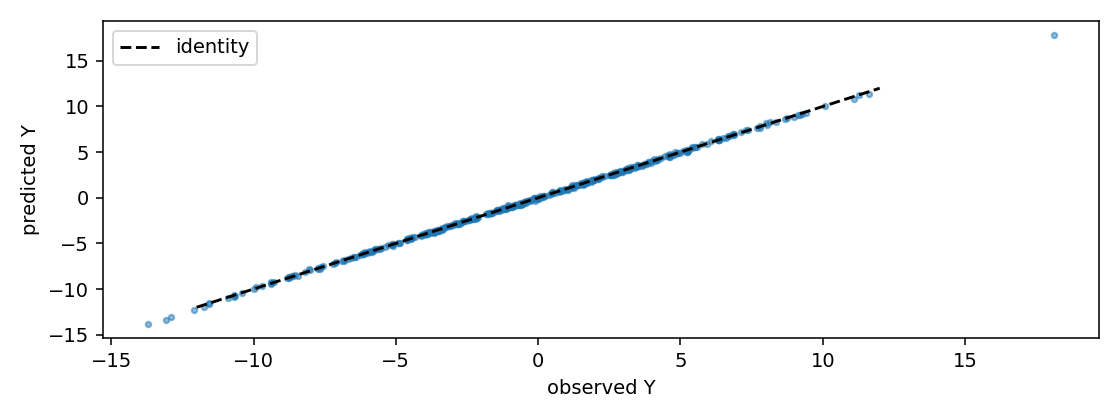

In [4]:
# 本地绘图并显示，无在线图片。
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO
pred = np.load('notebook_outputs/predictions.npz', allow_pickle=False)
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(data['test_y'],pred['test_prediction'],s=8,alpha=.5)
ax.plot([-12,12],[-12,12],'--',color='black',label='identity')
ax.set(xlabel='observed Y',ylabel='predicted Y')
ax.legend()
fig.tight_layout()
# 将真实新图编码为PNG，让Notebook离线打开也可见。
buf = BytesIO()
fig.savefig(buf, format='png', dpi=140)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 自我检查
把本次数字与answers.md比较。预测准确、数学实现正确和因果/域外主张是不同问题；请分别写出证据和限制。